In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
# Load dataset
data = pd.read_csv("diabetes.csv")
X = torch.tensor(data.drop("Outcome", axis=1).values, dtype=torch.float32)
y = torch.tensor(data["Outcome"].values, dtype=torch.float32).view(-1, 1)


In [ ]:
# Deep neural network with Sigmoid (causes vanishing gradients)
class DeepSigmoidNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 32),
            nn.Sigmoid(),
            nn.Linear(32, 32),
            nn.Sigmoid(),
            nn.Linear(32, 32),
            nn.Sigmoid(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
model = DeepSigmoidNet()
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [ ]:
# Forward + backward
y_pred = model(X)
loss = loss_fn(y_pred, y)

In [ ]:
optimizer.zero_grad()
loss.backward()

In [ ]:
# Collect gradient magnitudes
grads = [p.grad.norm().item() for p in model.parameters() if p.grad is not None]

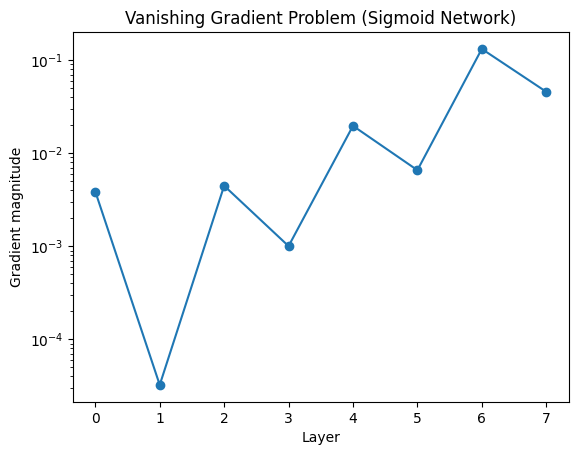

In [ ]:
# Plot gradients
plt.plot(grads, marker='o')
plt.yscale('log')
plt.xlabel("Layer")
plt.ylabel("Gradient magnitude")
plt.title("Vanishing Gradient Problem (Sigmoid Network)")
plt.show()